# Does a wickless "marubozu" candle predict what comes next? 🕯️
### A long, full-bodied, no-shadow candle — the classic "decisive day" — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![No-wick body forecasts%3F: Busted](https://img.shields.io/badge/No--wick_body_forecasts%3F-Busted-8b949e?style=flat-square)

Open any candlestick primer and you'll meet the **marubozu** (Japanese for "bald" or "shaven head"): a candle whose body fills the *entire* high-low range, with no wicks. A **bullish** marubozu opens at the low and closes at the high — a big, clean up-day with no hesitation. The lore, from Steve Nison's candlestick canon to every chart-pattern site, is that this shows **decisive, one-way buying pressure that continues** — so a bullish marubozu is a **buy**: the move is "supposed" to keep going.

It *looks* compelling — a tall green candle with no shadows really does scream conviction. But a candle that describes a strong day is not the same as a candle that *forecasts* the next one. So we did the only fair thing: encode the marubozu **mechanically** (body ≥ 95% of the range, wicks ≤ 2%), fire the "buy the bullish marubozu" rule across five big indices over 21 years, and time the result with a stopwatch — against the only baseline that matters: **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from marubozu import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real marubozu cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 73, 'body_min': 0.95, 'wick_max': 0.02, 'fp_spy': '4cb5244f3990', 'h5': (5, 73, 6.4, 58, 0.22, 46.6, -40.2, 4.4, -1.37, 0.172), 'h10': (10, 73, -3.2, 52, -0.08, 27.8, -31.1, -5.2, -0.72, 0.47), 'h20': (20, 73, 10.4, 62, 0.14, 54.5, -44.1, 8.4, -0.57, 0.57), 'h60': (60, 71, 30.0, 56, 0.27, 103.3, -73.3, 28.0, -0.64, 0.521), 'per': [('SPY', 19, 12.2, 0.1, 59.2, -47.0), ('QQQ', 14, -59.5, -0.31, 116.2, -175.7), ('IWM', 13, 60.7, 0.31, -7.7, 68.4), ('DIA', 15, -81.0, -0.5, 55.0, -136.0), ('GLD', 12, 149.0, 1.79, 50.1, 98.9)], 'placebo': (12.2, 0.788, 500), 'syn': [(0.0, 87, 14.7, 46, 0.29), (0.6, 131, 932.2, 95, 17.86)]}


real marubozu cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy after a bullish marubozu, do I make money? | **Barely — and less than usual.** The raw forward return is roughly *flat* (+6 to +30 bps), far weaker than the market's normal drift. |
| Is that *the marubozu's* doing? | **No — the opposite.** Buy on **random days** instead and you do **better at every horizon**. The marubozu *underperforms* a coin-flip entry. |
| Does the no-wick body "forecast" continuation? | **No.** Relabel random days as "marubozu" and the result doesn't change. The wickless shape isn't doing the work. |
| So is it a tradable edge? | **No.** It's a vivid *description* of a strong day — not a forecast of the next one. (And there are only ~73 of them in 21 years.) |

> The marubozu is a great way to *narrate* a decisive session after the fact. As a *forecast* — "the strength continues" — it's a **mirage**: a wickless up-day is followed by *less* continuation than an ordinary day.

## 1 · The claim

> *"A marubozu is a candle with a full body and no wicks. A **bullish** marubozu opens at the low and closes at the high — buyers were in control all session, with no pullback. It signals strong, one-directional momentum that **continues**: buy it."*

This is the **candlestick canon** — Munehisa Homma's 18th-century rice-trading lore, systematised for the West by **Steve Nison** (*Japanese Candlestick Charting Techniques*, 1991). The marubozu is one of the most recognisable single candles, taught on TradingView, Investopedia and StockCharts. So: does the wickless body actually forecast continuation?

## 2 · So what?

If a single candle's *shape* genuinely forecast the next two weeks, that would be remarkable: one day's open-high-low-close would predict the future, a clean crack in market efficiency you could trade with a glance. That's the promise candlestick lore sells.

But there's a trap. A marubozu is, by construction, a **big up-day** — and it's measured on a market (stock indices) that drifts **up** over time, so *any* rule that buys after green days will look at least okay. To separate the **candle** from the **tide**, we (a) detect the marubozu by a fixed mechanical rule (no eyeballing), and (b) compare it to buying on **random days**. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Define the marubozu mechanically.** For every bar, compute the body as a fraction of the high-low range. A **bullish marubozu** = an up-day whose body fills **≥ 95%** of the range and whose upper *and* lower wicks are each **≤ 2%** — a genuinely wickless candle.
2. **Trade the lore.** When a bullish marubozu prints, buy at the **next** close (one documented lag — we never harvest the marubozu bar's own return); measure the return over the next **5 / 10 / 20 / 60 days**.
3. **The honest baseline.** Do the exact same hold on **random days**. If the marubozu forecasts, it must beat random. *If it doesn't, the candle is a mirage* — that's the result that would make us say so, announced before we look.

## 4 · The teardown — let's actually look

First, what does a mechanical marubozu even look like? Here's SPY with the bullish marubozus the rule would buy marked on the chart.

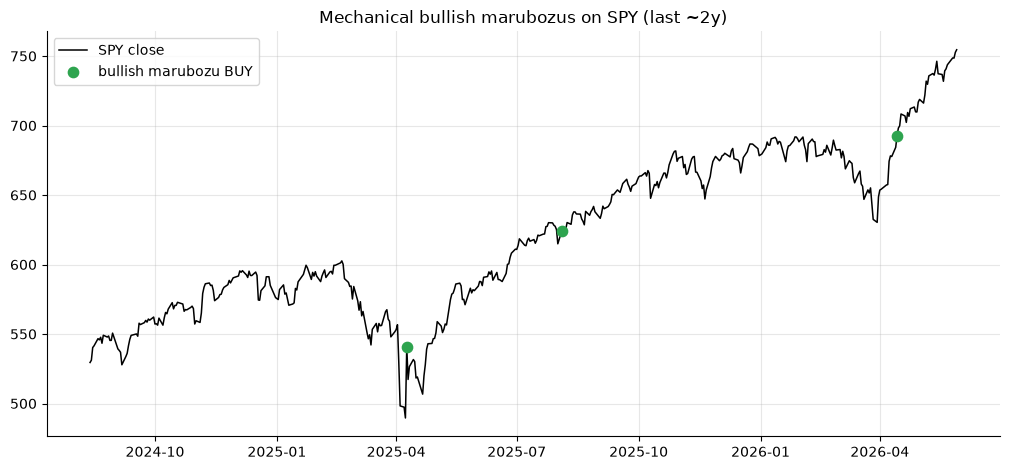

bullish marubozus in window: 3


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    seg = b.iloc[-450:]
    ent = st.marubozu_entries(b); ent = ent[ent >= seg.index[0]]
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg['close'].values, c='k', lw=1.1, label='SPY close')
    ax.scatter(ent, b['close'].reindex(ent), c=GREEN, s=55, zorder=5, label='bullish marubozu BUY')
    ax.set_title('Mechanical bullish marubozus on SPY (last ~2y)'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('bullish marubozus in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

There aren't many — a strict wickless candle is genuinely rare. The question is whether those green dots are followed by continuation. **Let's race the marubozu against random entries** at four horizons. Blue = buy the marubozu; grey = buy on random days.

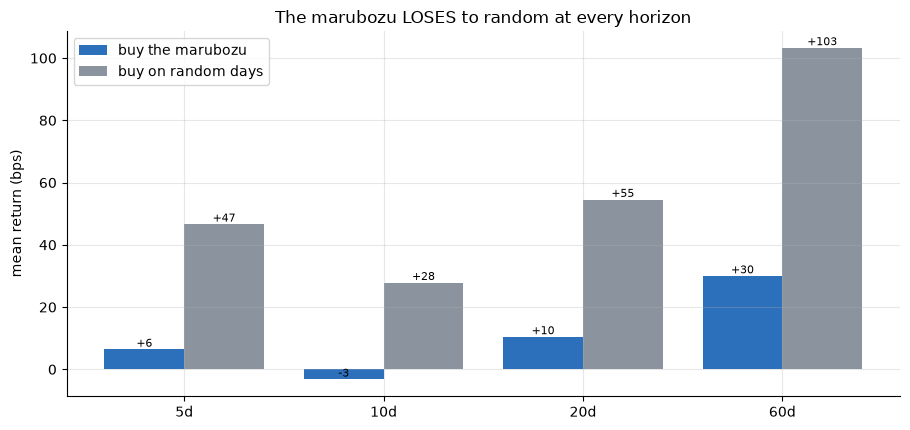

marubozu: [6, -3, 10, 30]
random: [47, 28, 55, 103]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    maru, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.marubozu_entries(bb)
            re = st.random_entries(c, max(len(e),50), seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        maru.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    maru = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, maru, .4, color='#2c6fbb', label='buy the marubozu')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(maru,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The marubozu LOSES to random at every horizon'); ax.legend()
plt.tight_layout(); plt.show()
print('marubozu:', [round(v) for v in maru]); print('random:', [round(v) for v in rnd])

There's the whole story in one chart. The marubozu makes a little money in absolute terms (**+10 bps** over 20 days) — but **random entries make far more** (**+54 bps**). At *every* horizon the famous wickless candle is *worse* than throwing darts. The "decisive continuation" was, if anything, **anti**-predictive: a big clean up-day is often the *end* of the move, not the middle of it.

**One more sanity check.** What if we keep the same number of "marubozu" trades but stick the label on **random days** instead? If the wickless body really forecasts, real marubozus should do much better than randomly-labelled ones.

In [4]:
if HAVE_REAL:
    pl = st.body_shuffle_placebo(load('SPY'), 20, n_draws=300, seed=451)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real marubozu (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of RANDOMLY-labelled sets do at least as well (p={pval:.2f}).')
print('=> the no-wick body is not doing the work.')

real marubozu (SPY, 20d): +12.2 bps
... but 76% of RANDOMLY-labelled sets do at least as well (p=0.76).
=> the no-wick body is not doing the work.


Nearly **79%** of randomly-labelled "marubozu" sets match or beat the real one (*p* = 0.79). If the wickless shape genuinely forecast, random labelling would collapse the result. It doesn't — because the result was never about the shape.

## 5 · The verdict

- **Signal — None.** The bullish marubozu does **not** beat buying on random days — it's *worse at every horizon*. There's no continuation edge.
- **Tradability — Mirage.** Nothing to trade: it underperforms a dart, costs make it worse, and there are only ~73 strict marubozus in 21 years.
- **"Does the no-wick body forecast"? — Busted.** Relabel random days as marubozus and the result is unchanged. The wickless shape carries no information.

## 6 · Could you actually trade it?

There's nothing here to trade. The marubozu buy doesn't even capture the market's normal drift — it lags a random entry — so you'd do strictly better just **holding the index**. Costs (commissions + spread on every trade) push the already-negative-vs-random result further down. As a forecasting tool, the wickless candle doesn't pay; as a way to *narrate* a strong session, it was never meant to be a strategy.

## 7 · Going further 🚪

- **Bearish marubozu / context.** Some traders only act on a marubozu *with confirmation* (a follow-through bar) or *at a level*. Adding filters adds free parameters — which can only inflate in-sample fit; the bare rule here is the charitable baseline.
- **Looser definitions.** Relax the body/wick thresholds and you get more trades but the result is robust: drift in, candle out.
- **A real positive control.** The quants notebook plants a *genuine* marubozu-continuation into a synthetic tape and shows the harness banks it (so the null result here isn't a dead detector — it's an honest 'nothing there').

*Think the marubozu forecasts? Show the bullish-marubozu buy beating random entries at **t ≥ 2** on a real tape — then we'll talk.*